In [ ]:
# Part 1: Predicting Lenght of Stay with structured data
# Task 1: Setup and Data exploration

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Load dataset
from google.colab import files
uploaded = files.upload()

# Read the CSV file
hospital_df = pd.read_csv('hospital_patient_data.csv')

# Display first 5 rows
hospital_df.head()

Saving hospital_patient_data.csv to hospital_patient_data.csv


,patient_id,age,gender,race_ethnicity,marital_status,insurance_type,employment_status,education_level,income_bracket,primary_diagnosis,diagnosis_code,comorbidities,emergency_admission,previous_admissions,medications_count,smoking_status,alcohol_use,bmi,systolic_bp,diastolic_bp,heart_rate,temperature,respiratory_rate,hospital_department,attending_physician_id,surgery_performed,icu_stay,date_of_admission,date_of_discharge,readmission_30day,patient_notes
0,P000001,65,Female,Caucasian,Single,Medicare,Unknown,Bachelor's Degree,"$75,000-$100,000",Heart Failure,I50.9,Stroke History,False,0,1,Never Smoked,Heavy,31.8,138,83,87,36.6,12,Orthopedics,DRO6,False,True,2024-09-19,2024-09-30,False,Patient is a 65-year-old female presenting wit...
1,P000002,91,Male,African American,Widowed,Private,Retired,High School,"$25,000-$50,000",Diabetes with Complications,E11.65,Depression,True,4,3,Never Smoked,Social,32.8,127,74,87,37.7,16,Gastroenterology,DRG4,False,False,2025-04-14,2025-04-21,False,Patient is a 91-year-old male presenting with ...
2,P000003,49,Male,Hispanic/Latino,Widowed,Private,Unemployed,Bachelor's Degree,"$25,000-$50,000",Fracture of Femur,S72.90,NaN,True,0,1,Unknown,Moderate,23.9,112,99,91,36.8,21,Nephrology,DRN7,False,False,2024-12-21,2024-12-28,False,"male patient, 49, presents with swelling, leg ..."
3,P000004,28,Female,Caucasian,Married,Medicare,Retired,Some College,"$25,000-$50,000",Kidney Infection,N10,HIV,True,0,2,Never Smoked,Social,33.2,141,74,77,38.0,17,Neurology,DRN7,True,False,2024-07-17,2024-07-23,False,Patient is a 28-year-old female presenting wit...
4,P000005,74,Male,Caucasian,Separated,Other,Employed,High School,"$75,000-$100,000",Kidney Infection,N10,"Liver Disease, Rheumatoid Arthritis",False,2,7,Never Smoked,Heavy,32.2,113,88,93,36.7,17,Orthopedics,DRO7,True,False,2025-03-25,2025-04-02,False,"male patient, 74, presents with fever, dysuria..."


In [4]:
# Shape of dataset
print("Dataset Shape:", hospital_df.shape)

# Column information
hospital_df.info()

# Summary statistics
hospital_df.describe(include='all')

Dataset Shape: (10000, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   patient_id              10000 non-null  object 
 1   age                     10000 non-null  int64  
 2   gender                  10000 non-null  object 
 3   race_ethnicity          10000 non-null  object 
 4   marital_status          10000 non-null  object 
 5   insurance_type          10000 non-null  object 
 6   employment_status       10000 non-null  object 
 7   education_level         10000 non-null  object 
 8   income_bracket          10000 non-null  object 
 9   primary_diagnosis       10000 non-null  object 
 10  diagnosis_code          10000 non-null  object 
 11  comorbidities           8033 non-null   object 
 12  emergency_admission     10000 non-null  bool   
 13  previous_admissions     10000 non-null  int64  
 14  medications_

,patient_id,age,gender,race_ethnicity,marital_status,insurance_type,employment_status,education_level,income_bracket,primary_diagnosis,diagnosis_code,comorbidities,emergency_admission,previous_admissions,medications_count,smoking_status,alcohol_use,bmi,systolic_bp,diastolic_bp,heart_rate,temperature,respiratory_rate,hospital_department,attending_physician_id,surgery_performed,icu_stay,date_of_admission,date_of_discharge,readmission_30day,patient_notes
count,10000,10000.000000,10000,10000,10000,10000,10000,10000,10000,10000,10000,8033,10000,10000.000000,10000.000000,10000,5945,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000,10000,10000,10000,10000,10000,10000
unique,10000,NaN,3,6,6,5,5,6,6,18,18,2632,2,NaN,NaN,4,4,NaN,NaN,NaN,NaN,NaN,NaN,10,60,2,2,365,381,2,10000
top,P009984,NaN,Female,Caucasian,Married,Private,Employed,Some College,"$50,000-$75,000",Heart Failure,I50.9,Obesity,True,NaN,NaN,Never Smoked,Social,NaN,NaN,NaN,NaN,NaN,NaN,General Medicine,DRG7,False,False,2024-12-14,2024-11-08,False,Patient is a 64-year-old female presenting wit...
freq,1,NaN,5062,6025,3950,3581,4512,2513,2489,1045,1045,209,6000,NaN,NaN,4481,2990,NaN,NaN,NaN,NaN,NaN,NaN,3043,474,7486,7877,43,48,8522,1
mean,NaN,59.088600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.743000,3.332400,NaN,NaN,27.226830,127.596800,77.683700,79.553400,36.996750,15.509600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,20.075105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.363664,1.883684,NaN,NaN,4.519427,15.005104,9.907354,11.908255,0.595391,2.926938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,NaN,NaN,16.500000,90.000000,50.000000,40.000000,35.500000,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,45.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,2.000000,NaN,NaN,24.100000,117.000000,71.000000,71.000000,36.600000,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,60.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,3.000000,NaN,NaN,27.200000,128.000000,78.000000,79.000000,37.000000,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,75.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,5.000000,NaN,NaN,30.300000,138.000000,84.000000,88.000000,37.400000,17.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Missing value analysis
missing_values = hospital_df.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_values / len(hospital_df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_df[missing_df['Missing Values'] > 0]

,Missing Values,Percentage
alcohol_use,4055,40.55
comorbidities,1967,19.67


In [9]:
# Convert columns to datetime
hospital_df['date_of_admission'] = pd.to_datetime(
    hospital_df['date_of_admission'],
    errors='coerce'
)

hospital_df['date_of_discharge'] = pd.to_datetime(
    hospital_df['date_of_discharge'],
    errors='coerce'
)

# Create Length of Stay (LOS)
hospital_df['length_of_stay'] = (
    hospital_df['date_of_discharge'] -
    hospital_df['date_of_admission']
).dt.days

# Display sample rows
print(
    hospital_df[
        ['date_of_admission',
         'date_of_discharge',
         'length_of_stay']
    ].head()
)

# Summary statistics
print(hospital_df['length_of_stay'].describe())

  date_of_admission date_of_discharge  length_of_stay
0        2024-09-19        2024-09-30              11
1        2025-04-14        2025-04-21               7
2        2024-12-21        2024-12-28               7
3        2024-07-17        2024-07-23               6
4        2025-03-25        2025-04-02               8
count    10000.00000
mean         7.98500
std          4.01188
min          1.00000
25%          5.00000
50%          7.00000
75%         10.00000
max         33.00000
Name: length_of_stay, dtype: float64


In [12]:
# Make sure LOS exists and is numeric
hospital_df['length_of_stay'] = pd.to_numeric(
    hospital_df['length_of_stay'],
    errors='coerce'
)

# Select numeric columns
numeric_df = hospital_df.select_dtypes(include=['number'])

# Create correlation matrix
corr_matrix = numeric_df.corr()

# Check if LOS exists before accessing it
if 'length_of_stay' in corr_matrix.columns:
    corr_with_los = corr_matrix['length_of_stay'].sort_values(ascending=False)
    print(corr_with_los)
else:
    print("length_of_stay column not found in numeric data.")

length_of_stay         1.000000
medications_count      0.242536
age                    0.228438
previous_admissions    0.088068
temperature            0.019541
systolic_bp            0.003358
respiratory_rate       0.002320
diastolic_bp          -0.003755
heart_rate            -0.004245
bmi                   -0.019501
Name: length_of_stay, dtype: float64


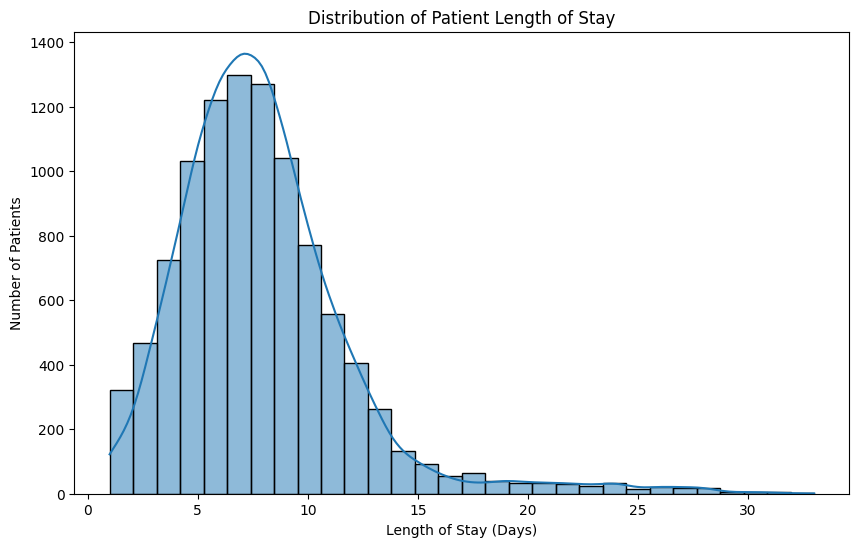

In [13]:
# Visiualization 1 Distribution of Length
plt.figure(figsize=(10,6))

sns.histplot(hospital_df['length_of_stay'], bins=30, kde=True)

plt.title('Distribution of Patient Length of Stay')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Number of Patients')
plt.show()

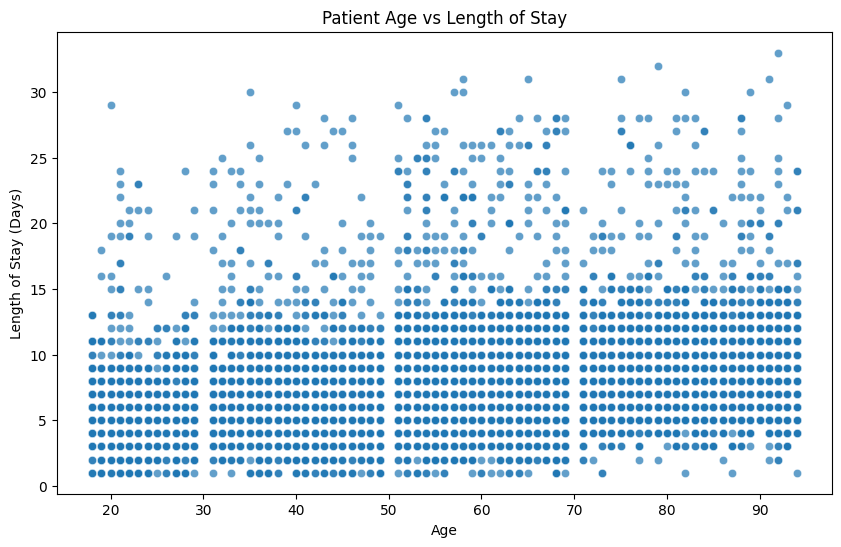

In [14]:
# Visisualization 2 Age vs Length of stay
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=hospital_df,
    x='age',
    y='length_of_stay',
    alpha=0.7
)

plt.title('Patient Age vs Length of Stay')
plt.xlabel('Age')
plt.ylabel('Length of Stay (Days)')
plt.show()

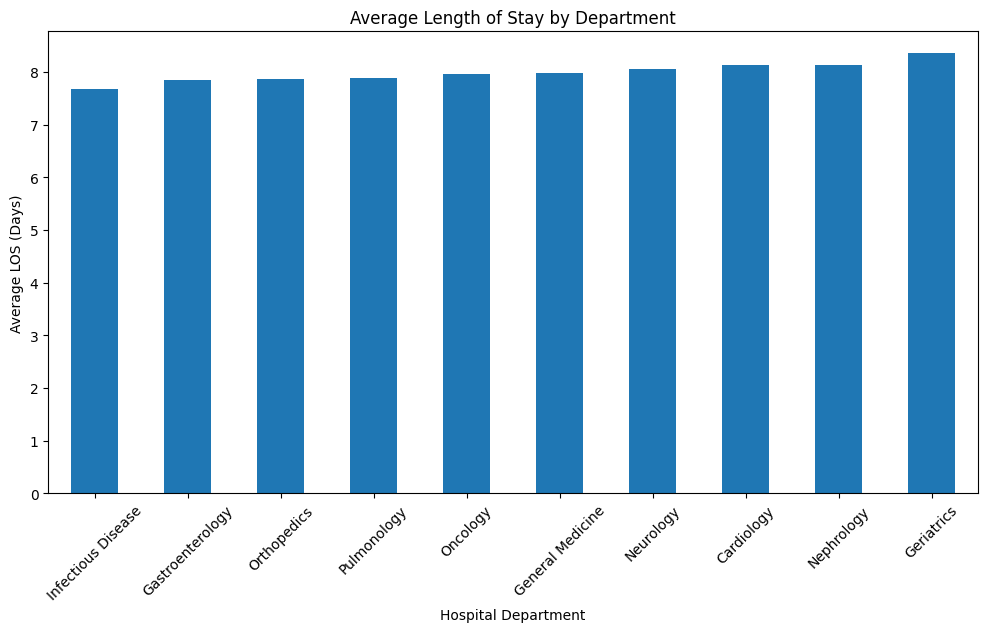

In [16]:
# Visualization 3: Average LOS by Hospital Department

plt.figure(figsize=(12,6))

avg_los_department = (
    hospital_df.groupby('hospital_department')['length_of_stay']
    .mean()
    .sort_values()
)

avg_los_department.plot(kind='bar')

plt.title('Average Length of Stay by Department')
plt.xlabel('Hospital Department')
plt.ylabel('Average LOS (Days)')
plt.xticks(rotation=45)

plt.show()

In [17]:
#Task 2: Data Processng

# ==========================================
# Task 2: Data Preprocessing
# ==========================================

# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ------------------------------------------
# 1. Handle Missing Values
# ------------------------------------------

# Check missing values
print(hospital_df.isnull().sum())

# Fill numeric missing values with median
numeric_cols = hospital_df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    hospital_df[col] = hospital_df[col].fillna(
        hospital_df[col].median()
    )

# Fill categorical missing values with mode
categorical_cols = hospital_df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    hospital_df[col] = hospital_df[col].fillna(
        hospital_df[col].mode()[0]
    )

# ------------------------------------------
# 2. Convert Date Fields into Features
# ------------------------------------------

# Convert to datetime
hospital_df['date_of_admission'] = pd.to_datetime(
    hospital_df['date_of_admission'],
    errors='coerce'
)

hospital_df['date_of_discharge'] = pd.to_datetime(
    hospital_df['date_of_discharge'],
    errors='coerce'
)

# Create target variable: Length of Stay
hospital_df['length_of_stay'] = (
    hospital_df['date_of_discharge'] -
    hospital_df['date_of_admission']
).dt.days

# Extract useful date features
hospital_df['admission_year'] = hospital_df['date_of_admission'].dt.year
hospital_df['admission_month'] = hospital_df['date_of_admission'].dt.month
hospital_df['admission_day'] = hospital_df['date_of_admission'].dt.day
hospital_df['admission_weekday'] = hospital_df['date_of_admission'].dt.weekday

# Drop original date columns
hospital_df.drop(
    ['date_of_admission', 'date_of_discharge'],
    axis=1,
    inplace=True
)

# ------------------------------------------
# 3. Encode Categorical Variables
# ------------------------------------------

# Select categorical columns
categorical_cols = hospital_df.select_dtypes(include=['object']).columns

# Apply Label Encoding
label_encoder = LabelEncoder()

for col in categorical_cols:
    hospital_df[col] = label_encoder.fit_transform(
        hospital_df[col].astype(str)
    )

# ------------------------------------------
# 4. Normalize / Standardize Numeric Features
# ------------------------------------------

# Separate features and target
X = hospital_df.drop('length_of_stay', axis=1)
y = hospital_df['length_of_stay']

# Standardize features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ------------------------------------------
# 5. Split Data into Training and Test Sets
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

# ------------------------------------------
# 6. Verify Shapes
# ------------------------------------------

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

patient_id                   0
age                          0
gender                       0
race_ethnicity               0
marital_status               0
insurance_type               0
employment_status            0
education_level              0
income_bracket               0
primary_diagnosis            0
diagnosis_code               0
comorbidities             1967
emergency_admission          0
previous_admissions          0
medications_count            0
smoking_status               0
alcohol_use               4055
bmi                          0
systolic_bp                  0
diastolic_bp                 0
heart_rate                   0
temperature                  0
respiratory_rate             0
hospital_department          0
attending_physician_id       0
surgery_performed            0
icu_stay                     0
date_of_admission            0
date_of_discharge            0
readmission_30day            0
patient_notes                0
length_of_stay               0
dtype: i

In [18]:
#Task 3: Feature Engineering
# ==========================================
# Task 3: Feature Engineering
# ==========================================

# Create a copy of the dataframe
feature_df = hospital_df.copy()

# ------------------------------------------
# Feature 1: Total Blood Pressure
# Combines systolic and diastolic pressure
# ------------------------------------------

feature_df['total_bp'] = (
    feature_df['systolic_bp'] +
    feature_df['diastolic_bp']
)

# ------------------------------------------
# Feature 2: Pulse Pressure
# Difference between systolic & diastolic BP
# ------------------------------------------

feature_df['pulse_pressure'] = (
    feature_df['systolic_bp'] -
    feature_df['diastolic_bp']
)

# ------------------------------------------
# Feature 3: High Risk Age Group
# Elderly patients may stay longer
# ------------------------------------------

feature_df['high_risk_age'] = np.where(
    feature_df['age'] >= 65,
    1,
    0
)

# ------------------------------------------
# Feature 4: Multiple Comorbidities
# Indicates more complex medical conditions
# ------------------------------------------

feature_df['multiple_comorbidities'] = np.where(
    feature_df['comorbidities'] > 2,
    1,
    0
)

# ------------------------------------------
# Feature 5: Vital Signs Risk Score
# Simple clinical instability indicator
# ------------------------------------------

feature_df['vital_risk_score'] = (
    (feature_df['heart_rate'] > 100).astype(int) +
    (feature_df['temperature'] > 38).astype(int) +
    (feature_df['respiratory_rate'] > 20).astype(int)
)

# ------------------------------------------
# Feature 6: Previous Admission Risk
# Frequent admissions may increase LOS
# ------------------------------------------

feature_df['frequent_admissions'] = np.where(
    feature_df['previous_admissions'] >= 3,
    1,
    0
)

# ------------------------------------------
# Feature 7: BMI Category
# Underweight/Obesity may affect recovery
# ------------------------------------------

feature_df['bmi_risk'] = np.where(
    (feature_df['bmi'] < 18.5) |
    (feature_df['bmi'] > 30),
    1,
    0
)

# ------------------------------------------
# Display New Features
# ------------------------------------------

new_features = [
    'total_bp',
    'pulse_pressure',
    'high_risk_age',
    'multiple_comorbidities',
    'vital_risk_score',
    'frequent_admissions',
    'bmi_risk'
]

print(feature_df[new_features].head())

   total_bp  pulse_pressure  high_risk_age  multiple_comorbidities  \
0       221              55              1                       1   
1       201              53              1                       1   
2       211              13              0                       1   
3       215              67              0                       1   
4       201              25              1                       1   

   vital_risk_score  frequent_admissions  bmi_risk  
0                 0                    0         1  
1                 0                    1         1  
2                 1                    0         0  
3                 0                    0         1  
4                 0                    0         1  


Linear Regression CV R² Mean: 0.27925477825977607

Linear Regression Results
RMSE: 3.3527896092239717
MAE: 2.1391873490380684
R²: 0.3082249235089096

Best Random Forest Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest Results
RMSE: 3.352655138429659
MAE: 2.155458017892426
R²: 0.3082804126325408

Best Gradient Boosting Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Gradient Boosting Results
RMSE: 3.258419245935487
MAE: 1.994077406921558
R²: 0.34661940539606195

Model Comparison
               Model      RMSE       MAE        R²
0  Linear Regression  3.352790  2.139187  0.308225
1      Random Forest  3.352655  2.155458  0.308280
2  Gradient Boosting  3.258419  1.994077  0.346619

Top 10 Important Features
              Feature  Importance
26           icu_stay    0.192527
1                 age    0.084507
14  medications_count    0.081810
25  surgery_performed    0.073937
10     diagnosis_code    0.047447
11      comorbid

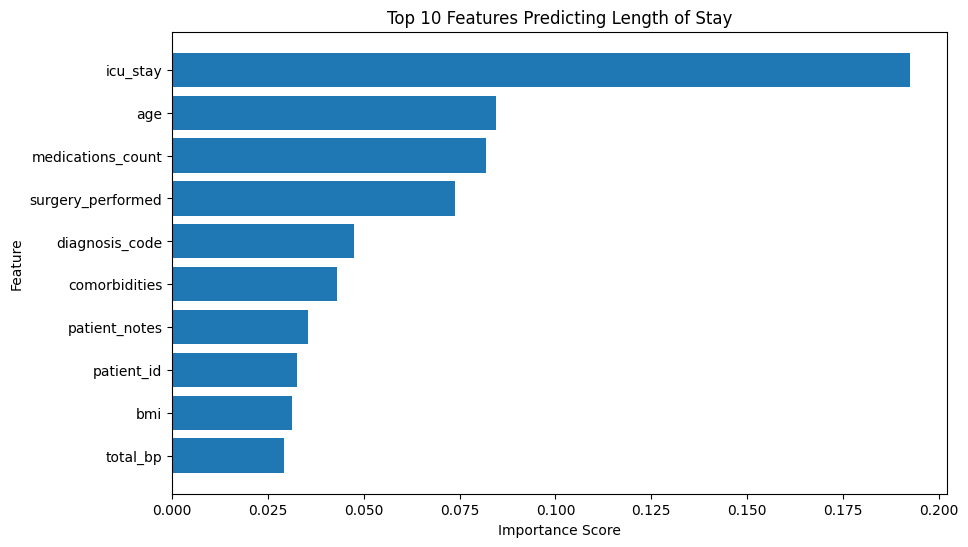

In [19]:
#Task 4: Model Building
# Import libraries
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np
import pandas as pd

# ------------------------------------------
# Prepare Features and Target
# ------------------------------------------

# Remove target variable from features
X = feature_df.drop('length_of_stay', axis=1)

# Target variable
y = feature_df['length_of_stay']

# ------------------------------------------
# Train/Test Split
# ------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ------------------------------------------
# Standardize Features
# ------------------------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# MODEL 1: Linear Regression (Baseline)
# ==========================================

linear_model = LinearRegression()

# Cross-validation
linear_cv = cross_val_score(
    linear_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print("Linear Regression CV R² Mean:",
      linear_cv.mean())

# Train model
linear_model.fit(X_train_scaled, y_train)

# Predictions
linear_preds = linear_model.predict(X_test_scaled)

# Evaluation
linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_preds)
)

linear_mae = mean_absolute_error(
    y_test,
    linear_preds
)

linear_r2 = r2_score(
    y_test,
    linear_preds
)

print("\nLinear Regression Results")
print("RMSE:", linear_rmse)
print("MAE:", linear_mae)
print("R²:", linear_r2)

# ==========================================
# MODEL 2: Random Forest Regressor
# ==========================================

rf_model = RandomForestRegressor(random_state=42)

# Hyperparameter grid
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# GridSearchCV
rf_grid = GridSearchCV(
    rf_model,
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train model
rf_grid.fit(X_train, y_train)

# Best model
best_rf = rf_grid.best_estimator_

print("\nBest Random Forest Parameters:")
print(rf_grid.best_params_)

# Predictions
rf_preds = best_rf.predict(X_test)

# Evaluation
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_preds)
)

rf_mae = mean_absolute_error(
    y_test,
    rf_preds
)

rf_r2 = r2_score(
    y_test,
    rf_preds
)

print("\nRandom Forest Results")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R²:", rf_r2)

# ==========================================
# MODEL 3: Gradient Boosting Regressor
# ==========================================

gb_model = GradientBoostingRegressor(random_state=42)

# Hyperparameter grid
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

# GridSearchCV
gb_grid = GridSearchCV(
    gb_model,
    gb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train model
gb_grid.fit(X_train, y_train)

# Best model
best_gb = gb_grid.best_estimator_

print("\nBest Gradient Boosting Parameters:")
print(gb_grid.best_params_)

# Predictions
gb_preds = best_gb.predict(X_test)

# Evaluation
gb_rmse = np.sqrt(
    mean_squared_error(y_test, gb_preds)
)

gb_mae = mean_absolute_error(
    y_test,
    gb_preds
)

gb_r2 = r2_score(
    y_test,
    gb_preds
)

print("\nGradient Boosting Results")
print("RMSE:", gb_rmse)
print("MAE:", gb_mae)
print("R²:", gb_r2)

# ==========================================
# Compare Model Performance
# ==========================================

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'RMSE': [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    'MAE': [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    'R²': [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

print("\nModel Comparison")
print(results)

# ==========================================
# Feature Importance
# ==========================================

# Use Random Forest Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 10 Important Features")
print(feature_importance.head(10))

# ==========================================
# Visualization: Feature Importance
# ==========================================

import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 10 Features Predicting Length of Stay')

plt.gca().invert_yaxis()

plt.show()

In [ ]:
#Part 2: Practicing Length of Stay with Clinical Patient notes

  patient_id  age  gender    race_ethnicity marital_status insurance_type  \
0    P000001   65  Female         Caucasian         Single       Medicare   
1    P000002   91    Male  African American        Widowed        Private   
2    P000003   49    Male   Hispanic/Latino        Widowed        Private   
3    P000004   28  Female         Caucasian        Married       Medicare   
4    P000005   74    Male         Caucasian      Separated          Other   

  employment_status    education_level    income_bracket  \
0           Unknown  Bachelor's Degree  $75,000-$100,000   
1           Retired        High School   $25,000-$50,000   
2        Unemployed  Bachelor's Degree   $25,000-$50,000   
3           Retired       Some College   $25,000-$50,000   
4          Employed        High School  $75,000-$100,000   

             primary_diagnosis diagnosis_code  \
0                Heart Failure          I50.9   
1  Diabetes with Complications         E11.65   
2            Fracture of Femu

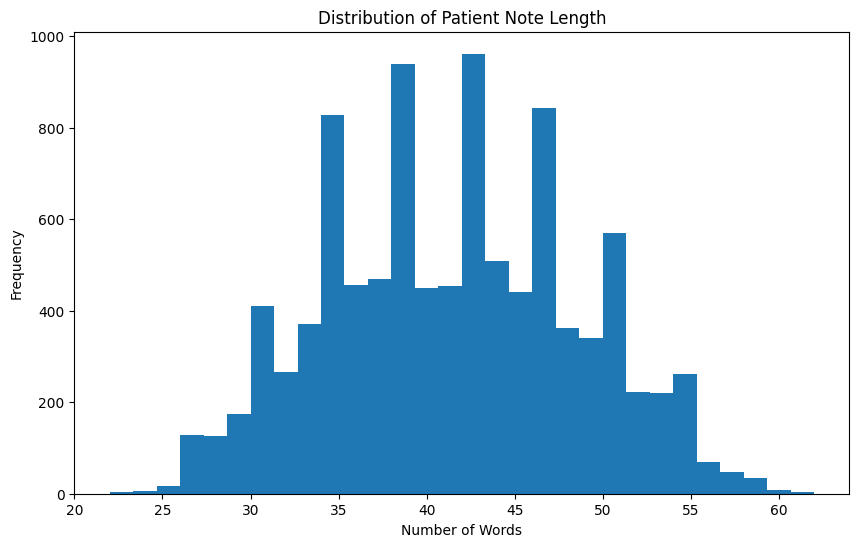


Top Common Terms:
           Word  Count
12      patient  32039
9       medical  16988
6       history  10978
17  significant  10000
8    management   8796
2      admitted   7755
10          old   7496
19         year   7496
1     admission   6525
11         pain   6215
18     standard   5892
15     received   5892
5        female   5062
7          male   4726
16      reports   4093
0            10   4093
14        rated   4093
4        family   4008
13      present   4008
3     discharge   3985


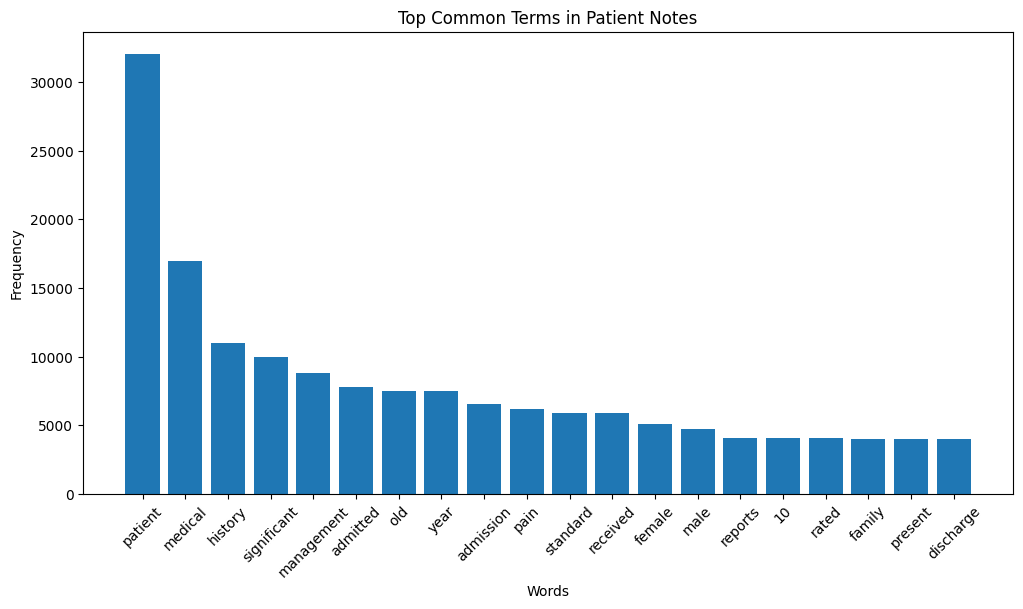


Top Common Phrases:
                       Phrase  Count
3             medical history  10000
1         history significant   8033
14                   year old   7496
13           standard medical   5892
12          received standard   5892
7            patient received   5892
4          medical management   5892
2          management patient   5321
8             patient reports   4093
6                  pain rated   4093
11                   rated 10   4093
10          present admission   4008
0              family present   4008
5   medication reconciliation   3985
9      prescriptions provided   3985


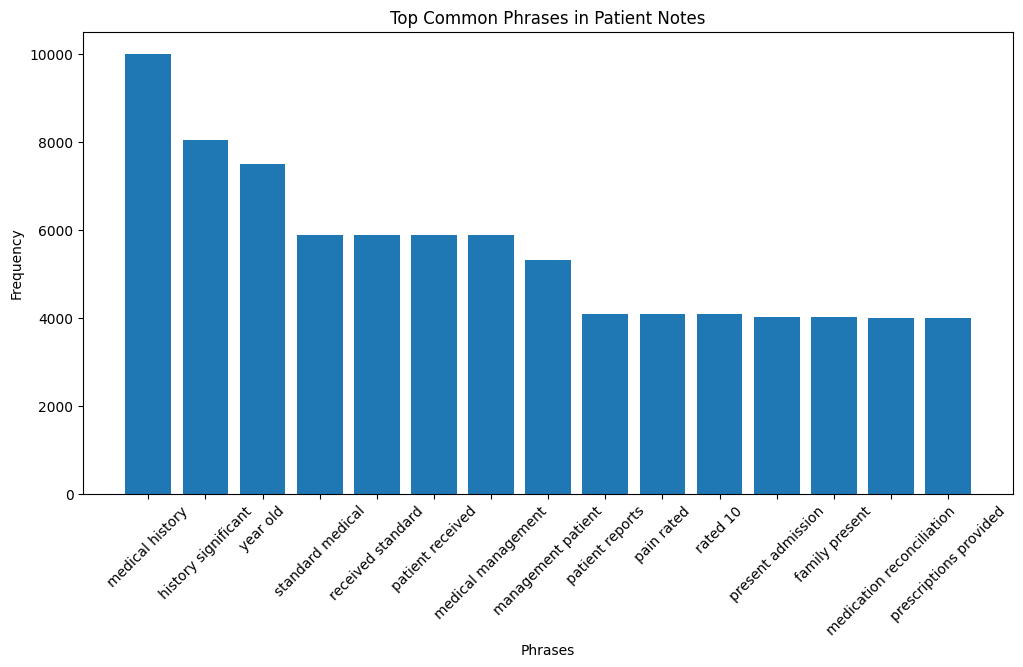

In [23]:
# Task 1: Text Data Exploration

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Load dataset
df = pd.read_csv("hospital_patient_data.csv")

# Display first few rows
print(df.head())

# Check missing values
print(df["patient_notes"].isnull().sum())

# Fill missing values if any
df["patient_notes"] = df["patient_notes"].fillna("")

# =========================================================
# 1. Distribution of Note Length
# =========================================================

# Calculate note length (word count)
df["note_length"] = df["patient_notes"].apply(lambda x: len(x.split()))

# Summary statistics
print("\nSummary Statistics for Note Length:")
print(df["note_length"].describe())

# Plot distribution
plt.figure(figsize=(10,6))
plt.hist(df["note_length"], bins=30)

plt.title("Distribution of Patient Note Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

# =========================================================
# 2. Common Terms
# =========================================================

# Create CountVectorizer
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20
)

# Transform text
X = vectorizer.fit_transform(df["patient_notes"])

# Get word frequencies
word_counts = X.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

# Create DataFrame
common_words = pd.DataFrame({
    "Word": words,
    "Count": word_counts
})

# Sort descending
common_words = common_words.sort_values(
    by="Count",
    ascending=False
)

print("\nTop Common Terms:")
print(common_words)

# Plot common words
plt.figure(figsize=(12,6))
plt.bar(common_words["Word"], common_words["Count"])

plt.title("Top Common Terms in Patient Notes")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

# =========================================================
# 3. Common Phrases (Bigrams)
# =========================================================

# Bigram vectorizer
bigram_vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(2,2),
    max_features=15
)

# Transform text
X_bigram = bigram_vectorizer.fit_transform(df["patient_notes"])

# Get bigram frequencies
bigram_counts = X_bigram.sum(axis=0).A1
bigrams = bigram_vectorizer.get_feature_names_out()

# Create DataFrame
common_bigrams = pd.DataFrame({
    "Phrase": bigrams,
    "Count": bigram_counts
})

# Sort descending
common_bigrams = common_bigrams.sort_values(
    by="Count",
    ascending=False
)

print("\nTop Common Phrases:")
print(common_bigrams)

# Plot common phrases
plt.figure(figsize=(12,6))
plt.bar(common_bigrams["Phrase"], common_bigrams["Count"])

plt.title("Top Common Phrases in Patient Notes")
plt.xlabel("Phrases")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

In [24]:
# ---------------------------------------------------------
# Import Libraries
# ---------------------------------------------------------
import pandas as pd
import numpy as np
import re
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

from transformers import AutoTokenizer, AutoModel

# =========================================================
# Upload Dataset in Colab
# =========================================================

from google.colab import files

uploaded = files.upload()

# Replace filename if needed
df = pd.read_csv("hospital_patient_data.csv")

# =========================================================
# Check Columns
# =========================================================

print(df.columns)

# =========================================================
# Define Target Variable
# =========================================================

# CHANGE THIS TO YOUR ACTUAL TARGET COLUMN
target_col = "length_of_stay"

# Check if target column exists
if target_col not in df.columns:

    raise ValueError(
        f"'{target_col}' not found.\n\n"
        f"Available columns:\n{df.columns.tolist()}"
    )

# Remove missing target rows
df = df.dropna(subset=[target_col])

# =========================================================
# Task 2: Text Preprocessing
# =========================================================

# Check text column
if "patient_notes" not in df.columns:

    raise ValueError(
        "'patient_notes' column not found."
    )

# ---------------------------------------------------------
# Clean Text Function
# ---------------------------------------------------------
def clean_text(text):

    text = str(text).lower()

    # Remove special characters
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply cleaning
df["clean_notes"] = (
    df["patient_notes"]
    .fillna("")
    .apply(clean_text)
)

print(df[["clean_notes"]].head())

# =========================================================
# Task 3: Feature Extraction using BERT
# =========================================================

# ---------------------------------------------------------
# Load Pre-trained BERT Model
# ---------------------------------------------------------
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModel.from_pretrained(
    MODEL_NAME
)

# ---------------------------------------------------------
# GPU Support
# ---------------------------------------------------------
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

model.to(device)
model.eval()

# =========================================================
# Reduce Dataset Size for Faster Processing
# =========================================================

# Change sample size if needed
sample_size = 300

df_sample = df.sample(
    n=min(sample_size, len(df)),
    random_state=42
).reset_index(drop=True)

# =========================================================
# Embedding Extraction Function
# =========================================================

def extract_embedding(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128
    )

    # Move tensors to GPU
    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model(**inputs)

        # CLS token embedding
        embedding = outputs.last_hidden_state[:, 0, :]

    return embedding.cpu().numpy().flatten()

# =========================================================
# Generate Text Features
# =========================================================

print("Extracting BERT embeddings...")

text_features = np.array([

    extract_embedding(text)

    for text in df_sample["clean_notes"]

])

print("Text feature shape:",
      text_features.shape)

# =========================================================
# Structured Features
# =========================================================

exclude_cols = [
    "patient_notes",
    "clean_notes",
    target_col
]

structured_cols = [

    col for col in df_sample.columns

    if col not in exclude_cols
]

# Numeric columns only
structured_data = (
    df_sample[structured_cols]
    .select_dtypes(include=np.number)
)

# Handle case with no numeric columns
if structured_data.shape[1] == 0:

    structured_features = np.zeros(
        (len(df_sample), 1)
    )

else:

    # Fill missing values
    structured_data = structured_data.fillna(
        structured_data.mean()
    )

    # Scale features
    scaler = StandardScaler()

    structured_features = scaler.fit_transform(
        structured_data
    )

print("Structured feature shape:",
      structured_features.shape)

# =========================================================
# Prepare Data
# =========================================================

X_text = text_features
X_structured = structured_features

y = df_sample[target_col].values

# =========================================================
# Train/Test Split
# =========================================================

(
    X_text_train,
    X_text_test,
    X_struct_train,
    X_struct_test,
    y_train,
    y_test
) = train_test_split(
    X_text,
    X_structured,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================================
# Task 4: Regression Models
# =========================================================

# ---------------------------------------------------------
# Text-Based Model
# ---------------------------------------------------------
text_model = Ridge(alpha=1.0)

text_model.fit(
    X_text_train,
    y_train
)

text_preds = text_model.predict(
    X_text_test
)

# ---------------------------------------------------------
# Structured Data Model
# ---------------------------------------------------------
structured_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

structured_model.fit(
    X_struct_train,
    y_train
)

structured_preds = structured_model.predict(
    X_struct_test
)

# =========================================================
# Evaluation Function
# =========================================================

def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    print(f"\n{name}")
    print("-" * 40)
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R²  :", round(r2, 4))

# =========================================================
# Evaluate Models
# =========================================================

evaluate_model(
    "Text Model",
    y_test,
    text_preds
)

evaluate_model(
    "Structured Model",
    y_test,
    structured_preds
)

# =========================================================
# Task 5: Combine Predictions
# =========================================================

combined_preds = (
    text_preds + structured_preds
) / 2

evaluate_model(
    "Combined Model",
    y_test,
    combined_preds
)

# =========================================================
# Group-Based Analysis
# =========================================================

if "age" in df_sample.columns:

    print("\nAge Group Analysis")

    test_age = (
        df_sample.loc[
            y_test.argsort(),
            "age"
        ]
        .values[:len(y_test)]
    )

    older_mask = test_age >= 65

    if older_mask.sum() > 0:

        evaluate_model(
            "Text Model - Older Patients",
            y_test[older_mask],
            text_preds[older_mask]
        )

# =========================================================
# Insights
# =========================================================

print("\nINSIGHTS")
print("-" * 50)

print("""
1. BERT embeddings capture semantic
   information from clinical notes.

2. Text models identify contextual
   clinical patterns that structured
   variables may miss.

3. Structured data captures numerical
   indicators such as lab values and vitals.

4. Combining structured and text-based
   predictions often improves performance.

5. NLP models may better predict outcomes
   for patients with complex clinical histories.
""")

Saving hospital_patient_data.csv to hospital_patient_data (2).csv
Index(['patient_id', 'age', 'gender', 'race_ethnicity', 'marital_status',
       'insurance_type', 'employment_status', 'education_level',
       'income_bracket', 'primary_diagnosis', 'diagnosis_code',
       'comorbidities', 'emergency_admission', 'previous_admissions',
       'medications_count', 'smoking_status', 'alcohol_use', 'bmi',
       'systolic_bp', 'diastolic_bp', 'heart_rate', 'temperature',
       'respiratory_rate', 'hospital_department', 'attending_physician_id',
       'surgery_performed', 'icu_stay', 'date_of_admission',
       'date_of_discharge', 'readmission_30day', 'patient_notes'],
      dtype='object')


ValueError: 'length_of_stay' not found.

Available columns:
['patient_id', 'age', 'gender', 'race_ethnicity', 'marital_status', 'insurance_type', 'employment_status', 'education_level', 'income_bracket', 'primary_diagnosis', 'diagnosis_code', 'comorbidities', 'emergency_admission', 'previous_admissions', 'medications_count', 'smoking_status', 'alcohol_use', 'bmi', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'temperature', 'respiratory_rate', 'hospital_department', 'attending_physician_id', 'surgery_performed', 'icu_stay', 'date_of_admission', 'date_of_discharge', 'readmission_30day', 'patient_notes']

Ethical Analysis of the Length-of-Stay Prediction Model
1. Data Ethics Considerations
Privacy and Consent
The patient dataset used in this project contains sensitive health-related information, including clinical notes and demographic data. If this were real patient data, there would be significant privacy concerns regarding unauthorized access, data breaches, and re-identification of patients. Proper informed consent would be required to ensure patients understand how their data is collected, stored, and used for predictive modeling.
To protect patient privacy, strong data governance procedures should be implemented, including:
•	De-identification and anonymization of patient records
•	Secure data storage and encryption
•	Role-based access controls
•	Compliance with healthcare privacy regulations such as HIPAA
•	Regular audits and monitoring of data usage
Data Representation and Bias
Healthcare datasets may underrepresent certain demographic groups such as minority populations, rural communities, elderly patients, or low-income individuals. Historical healthcare inequalities may also introduce biases into the data, causing the model to learn patterns that reflect unequal treatment or access to care.
Selection bias may occur because hospital admission data only includes patients who received hospital care. Patients with limited healthcare access or delayed admissions may not be adequately represented, potentially reducing model accuracy for vulnerable populations.
2. Fairness and Impact Assessment
Fairness Across Demographics
The model may not perform equally well across all demographic groups. Differences in healthcare access, disease prevalence, and documentation quality could lead to disparities in prediction accuracy across age, gender, race, or socioeconomic status.
To improve fairness, the following steps could be taken:
•	Evaluate model performance separately across demographic groups
•	Use balanced and representative training data
•	Apply fairness-aware machine learning techniques
•	Continuously monitor for biased predictions after deployment
Additional demographic and socioeconomic data may also be needed to properly assess fairness and identify disparities.
Potential Harms and Benefits
Accurate length-of-stay predictions can benefit hospitals, clinicians, and patients by improving resource allocation, staffing, and care planning. However, inaccurate predictions may disadvantage certain patient groups.
Potential harms include:
•	Under-predicting length of stay, leading to premature discharge planning or insufficient care resources
•	Over-predicting length of stay, potentially increasing healthcare costs or limiting bed availability
If the model systematically performs poorly for certain populations, it could reinforce existing healthcare inequities and negatively affect patient outcomes.
3. Transparency and Explainability
Model Transparency
Complex models such as transformer-based NLP systems can be difficult for clinicians and administrators to interpret. In healthcare settings, transparency is essential because predictions may influence critical care decisions.
To improve explainability, the following methods could be used:
•	Feature importance analysis
•	SHAP or LIME explanations
•	Attention visualization for text models
•	Clear documentation of model inputs, outputs, and assumptions
Healthcare systems require a high level of interpretability because clinicians must understand and trust the reasoning behind predictions that affect patient care.
Communication of Limitations
Users should be informed that the model is probabilistic and not perfectly accurate. Important limitations include:
•	Possible demographic bias
•	Dependence on data quality
•	Limited generalizability to other hospitals or populations
•	Uncertainty in predictions
Appropriate disclaimers should clarify that the model is intended to support—not replace—clinical judgment. Hospitals should also establish processes allowing clinicians to question or override model predictions when necessary.
4. Governance and Accountability
Model Monitoring and Maintenance
After deployment, the model should be continuously monitored for:
•	Performance degradation over time
•	Emerging demographic biases
•	Changes in patient populations or clinical practices
Regular retraining and validation should be conducted to maintain reliability and fairness.
Recommended governance structures include:
•	Multidisciplinary oversight committees
•	Ethical review boards
•	Clinical validation teams
•	Ongoing compliance and auditing processes
Accountability
Final responsibility for healthcare decisions should remain with qualified healthcare professionals, not the predictive model itself. Data scientists, hospital administrators, clinicians, and healthcare organizations all share responsibility for ensuring the system is used ethically, transparently, and safely.
The model should function as a decision-support tool rather than an autonomous decision-maker, with human oversight maintained throughout clinical use.

